# Delay Characterization: Cross-Correlation & Mutual Information (Lorenz Delayed)

**Objective:** Identify time lag between a Lorenz x-variable and its delayed version using:
1. **Cross-correlation** (using `scipy.signal.correlate` + `scipy.signal.correlation_lags`)
2. **Mutual Information** (histogram-based estimator)

True delay: 30 steps at dt=0.01, sampling_rate=100 → 10.3 t.u. delay.
Classic chaotic regime: a=10.0, b=28.0, c=8/3
This delay is known and used as ground truth for validation.

In [1]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate, correlation_lags
from sklearn.feature_selection import mutual_info_regression

from synch_analysis import (
    BelousovZhabotinskyDataSource,
)

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})

In [3]:
# --- DATA SOURCE SETUP ---
bz_delayed = BelousovZhabotinskyDataSource(
    f=1.0,           # Stoichiometric parameter (oscillation regime)
    q=0.05,          # Small parameter (controls oscillation amplitude)
    eps=0.02,        # Time-scale separation
    dt=0.01,
    initial_values=[0.1, 0.1],
    iterations=5000,
    variable='x',
    delay_steps=30,  # True delay to recover (0.3 t.u. at 100 1/(t.u.))
    noise_std=0.01,   # Add noise to BOTH signals
    sampling_rate=100.0,
    transient=2000,   # Discard first 2000 samples (transient)
)

signal_pair = bz_delayed.load()
s1 = signal_pair.signal_a
s2 = signal_pair.signal_b
sr = signal_pair.sampling_rate
true_delay = 30  # steps
true_delay_tu = true_delay / sr

print(f'Signal A: {signal_pair.name_a} ({len(s1)} samples)')
print(f'Signal B: {signal_pair.name_b} ({len(s2)} samples)')
print(f'Sampling rate: {sr} 1/(t.u.)')
print(f'True delay: {true_delay} steps ({true_delay_tu:.3f}s)')


Signal A: BZ x (delayed by 30 steps) (3000 samples)
Signal B: BZ x (source) (3000 samples)
Sampling rate: 100.0 1/(t.u.)
True delay: 30 steps (0.300s)


## 1. Cross-Correlation Method

In [4]:
# --- CROSS-CORRELATION ---

# Normalize signals
s1_norm = (s1 - np.mean(s1)) / np.std(s1)
s2_norm = (s2 - np.mean(s2)) / np.std(s2)

# Compute cross-correlation
corr = correlate(s1_norm, s2_norm, mode='full')
lags = correlation_lags(len(s1_norm), len(s2_norm), mode='full')

# Find peak
peak_idx = np.argmax(corr)
cc_lag = lags[peak_idx]
cc_max = corr[peak_idx]
cc_lag_tu = cc_lag / sr

print(f'Cross-correlation peak at lag: {cc_lag} steps ({cc_lag_tu:.3f}s)')
print(f'Max correlation: {cc_max:.4f}')

Cross-correlation peak at lag: 30 steps (0.300s)
Max correlation: 2967.3649


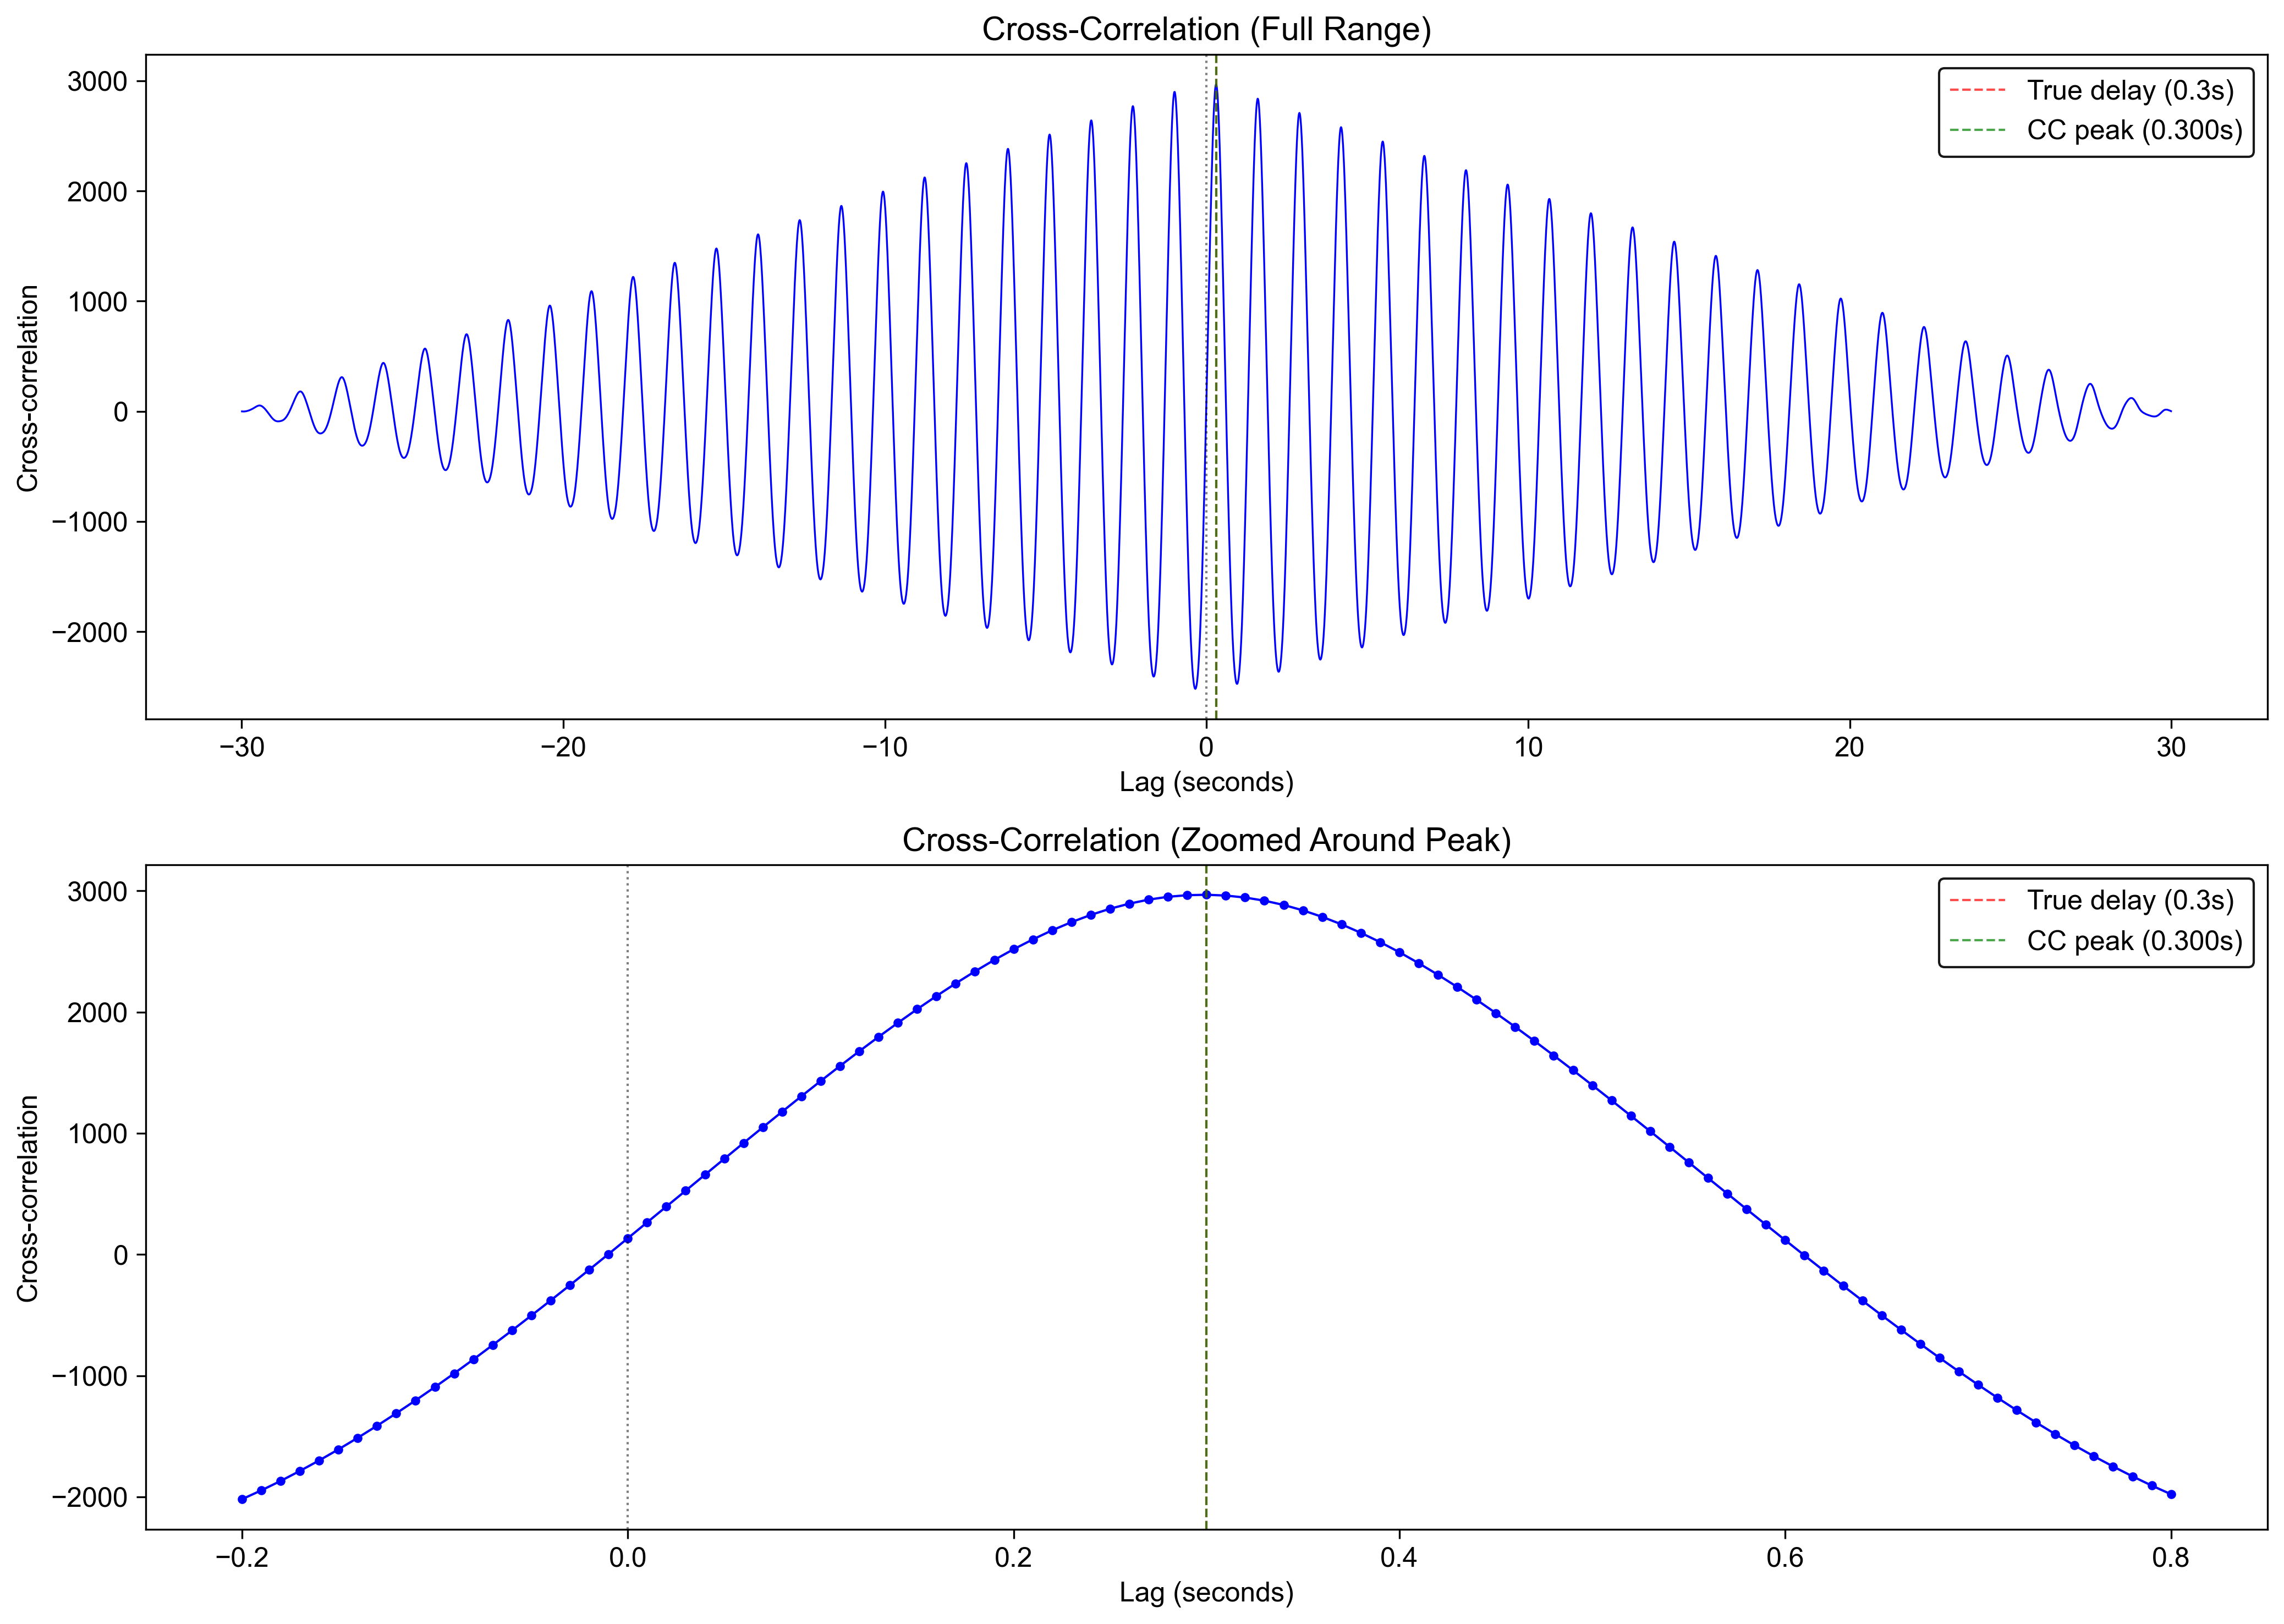

In [5]:
# Plot cross-correlation
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0].plot(lags / sr, corr, 'b-', linewidth=0.8)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f}s)')
axes[0].axvline(x=cc_lag_tu, color='g', linestyle='--', alpha=0.7, label=f'CC peak ({cc_lag_tu:.3f}s)')
axes[0].set_xlabel('Lag (t.u.)')
axes[0].set_ylabel('Cross-correlation')
axes[0].set_title('Cross-Correlation (Full Range)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

zoom_range = 50
mask = (lags >= cc_lag - zoom_range) & (lags <= cc_lag + zoom_range)
axes[1].plot(lags[mask] / sr, corr[mask], 'b-o', linewidth=1, markersize=3)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f}s)')
axes[1].axvline(x=cc_lag_tu, color='g', linestyle='--', alpha=0.7, label=f'CC peak ({cc_lag_tu:.3f}s)')
axes[1].set_xlabel('Lag (t.u.)')
axes[1].set_ylabel('Cross-correlation')
axes[1].set_title('Cross-Correlation (Zoomed Around Peak)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## 2. Mutual Information Method

In [6]:
# --- MUTUAL INFORMATION (sklearn) ---

def mutual_info_lag_sklearn(s1, s2, max_lag):
    """Compute mutual information for different lags using sklearn."""
    mi_values = []
    lags = np.arange(-max_lag, max_lag + 1)
    
    for lag in lags:
        if lag > 0:
            s1_shifted = s1[lag:]
            s2_shifted = s2[:-lag]
        elif lag < 0:
            s1_shifted = s1[:lag]
            s2_shifted = s2[-lag:]
        else:
            s1_shifted = s1
            s2_shifted = s2
        
        mi = mutual_info_regression(s1_shifted.reshape(-1, 1), s2_shifted, n_neighbors=5, random_state=0)
        mi_values.append(mi[0])
    
    return lags, np.array(mi_values)

max_lag = 250
mi_lags, mi_values = mutual_info_lag_sklearn(s1_norm, s2_norm, max_lag)

mi_peak_idx = np.argmax(mi_values)
mi_lag = mi_lags[mi_peak_idx]
mi_max = mi_values[mi_peak_idx]
mi_lag_tu = mi_lag / sr

print(f'Mutual Information peak at lag: {mi_lag} steps ({mi_lag_tu:.3f}s)')
print(f'Max MI: {mi_max:.4f}')

Mutual Information peak at lag: 30 steps (0.300s)
Max MI: 2.0555


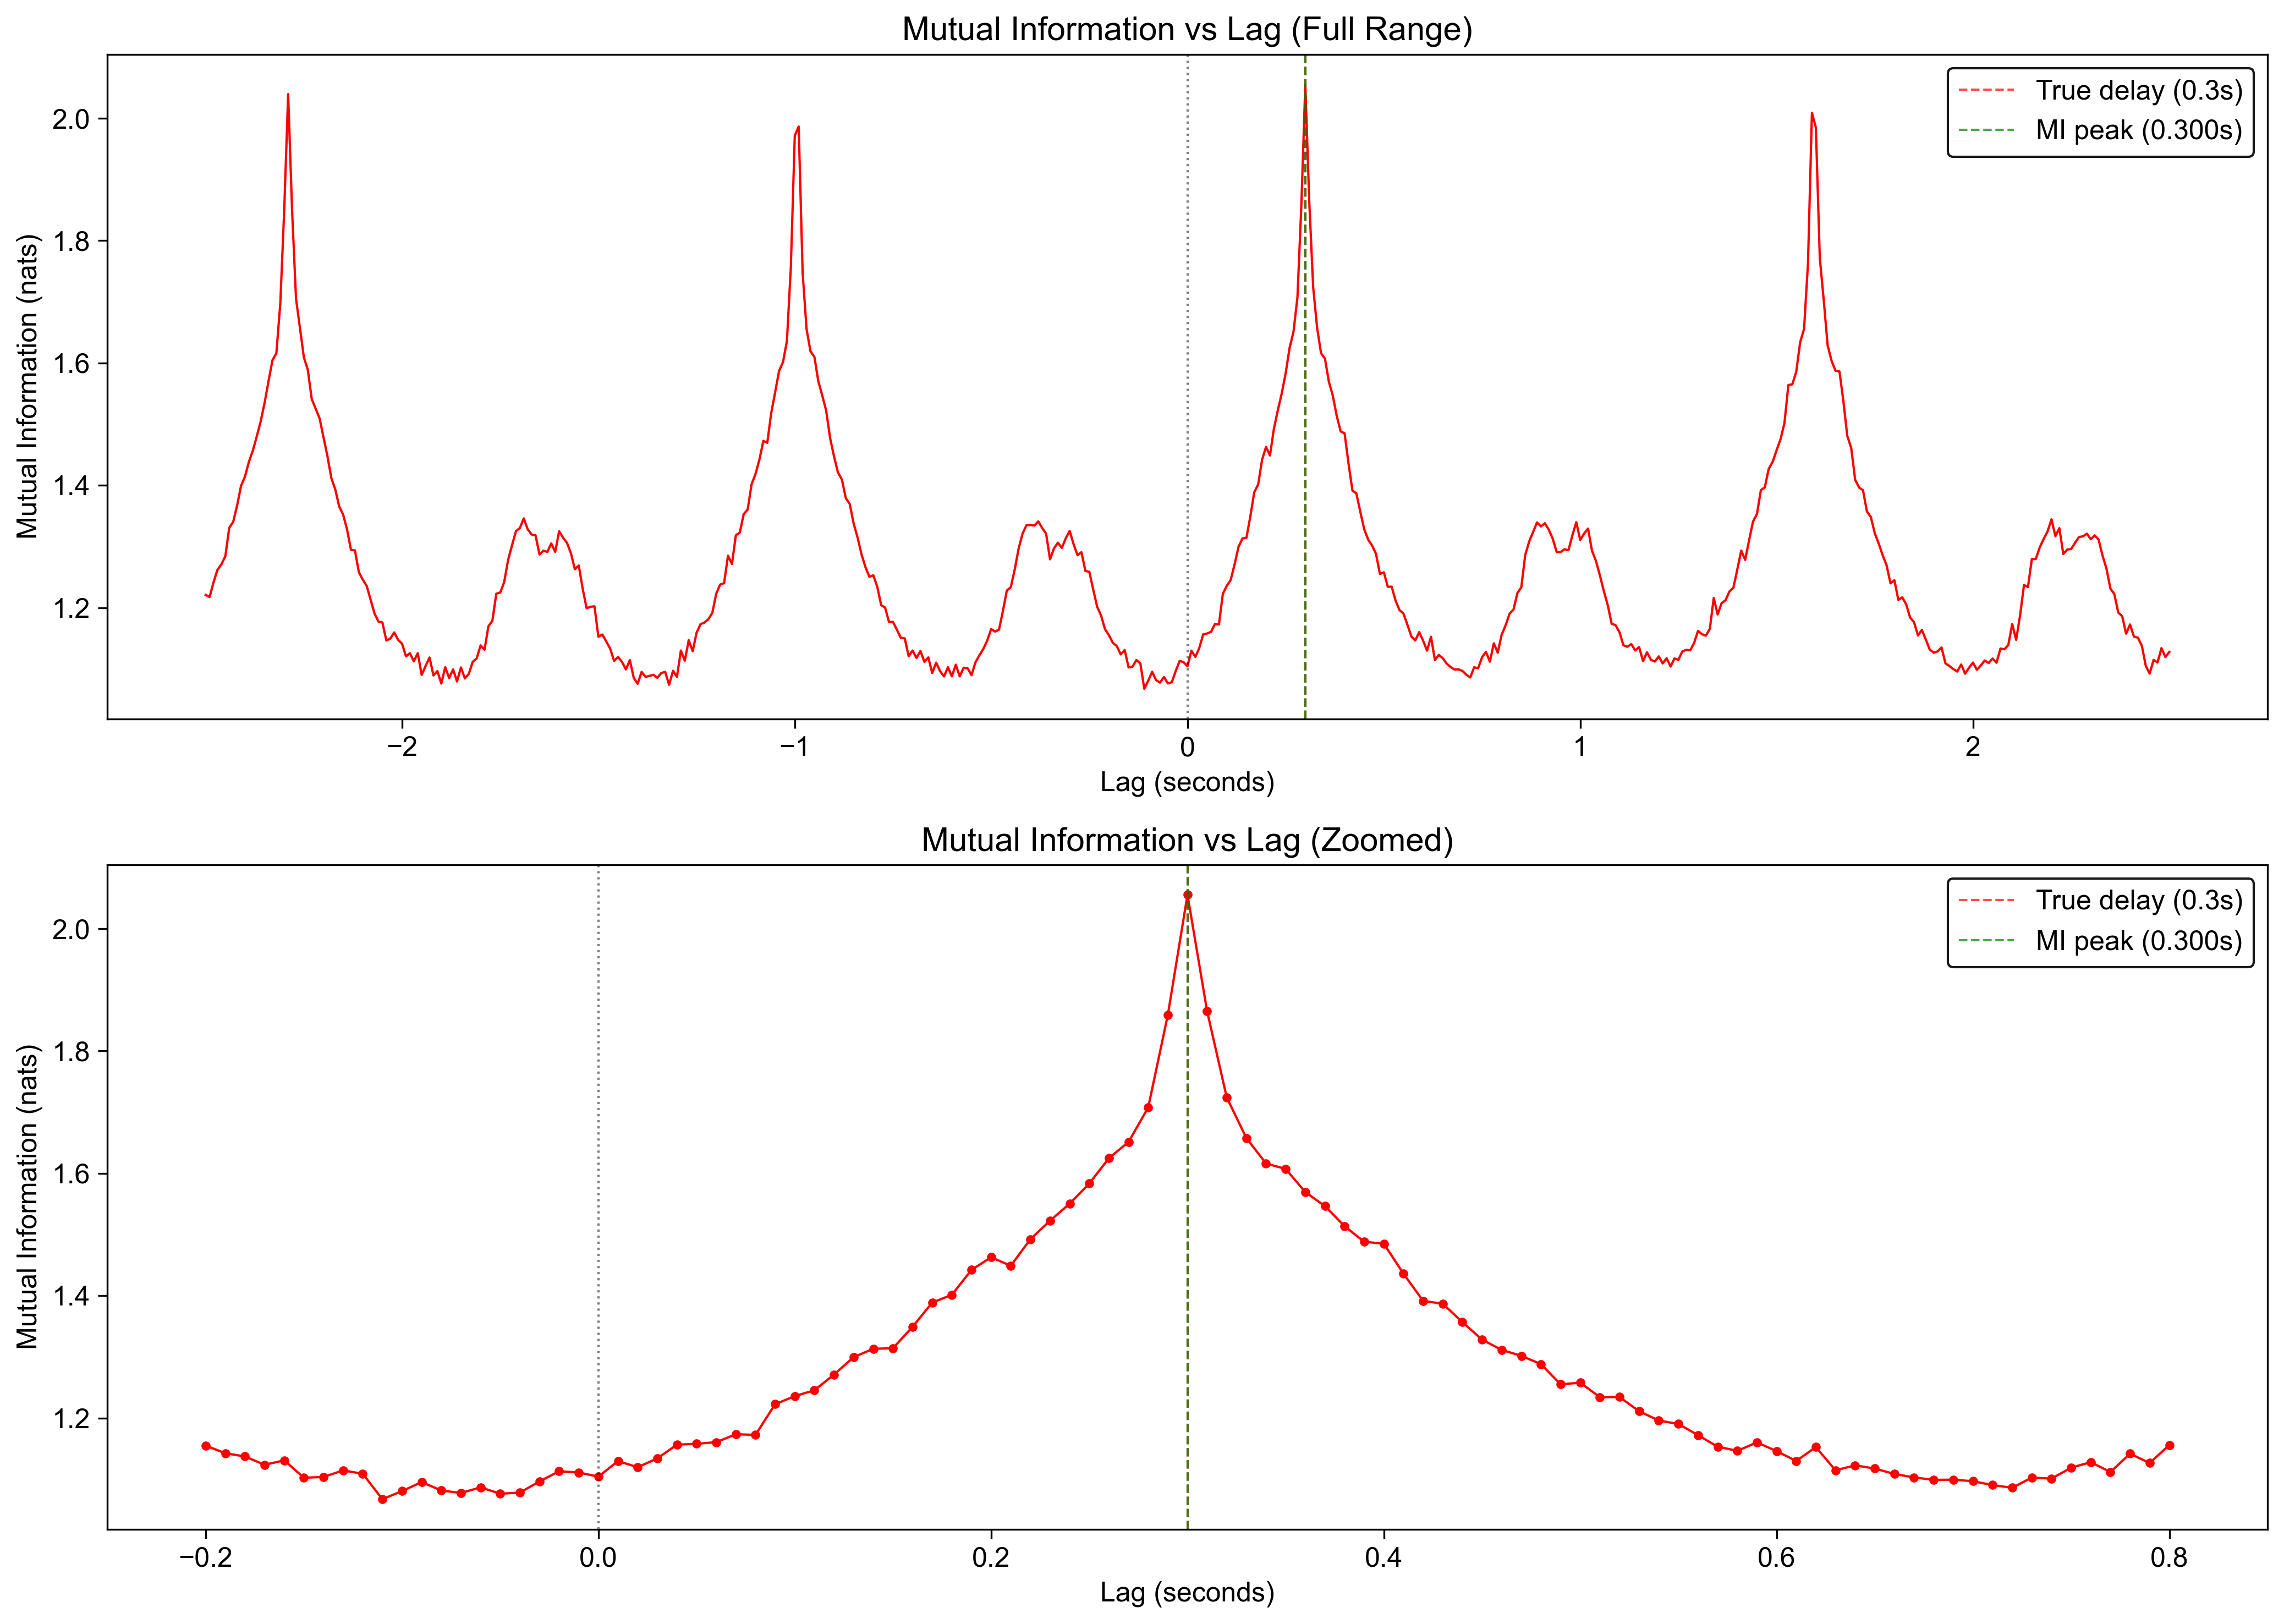

In [7]:
# Plot mutual information
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0].plot(mi_lags / sr, mi_values, 'r-', linewidth=1)
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f}s)')
axes[0].axvline(x=mi_lag_tu, color='g', linestyle='--', alpha=0.7, label=f'MI peak ({mi_lag_tu:.3f}s)')
axes[0].set_xlabel('Lag (t.u.)')
axes[0].set_ylabel('Mutual Information (nats)')
axes[0].set_title('Mutual Information vs Lag (Full Range)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

zoom_range = 50
mask = (mi_lags >= mi_lag - zoom_range) & (mi_lags <= mi_lag + zoom_range)
axes[1].plot(mi_lags[mask] / sr, mi_values[mask], 'r-o', linewidth=1, markersize=3)
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=true_delay_tu, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_tu:.1f}s)')
axes[1].axvline(x=mi_lag_tu, color='g', linestyle='--', alpha=0.7, label=f'MI peak ({mi_lag_tu:.3f}s)')
axes[1].set_xlabel('Lag (t.u.)')
axes[1].set_ylabel('Mutual Information (nats)')
axes[1].set_title('Mutual Information vs Lag (Zoomed)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## 3. Comparison of Methods

In [8]:
# --- COMPARISON ---

print(f"{'Method':<25} {'Lag (steps)':<15} {'Lag (t.u.)':<15} {'Error (steps)'}")
print(f"{'-'*70}")
print(f"{'True delay':<25} {true_delay:<15} {true_delay_tu:<15.3f} {0}")
print(f"{'Cross-Correlation':<25} {cc_lag:<15} {cc_lag_tu:<15.3f} {abs(cc_lag - true_delay)}")
print(f"{'Mutual Information':<25} {mi_lag:<15} {mi_lag_tu:<15.3f} {abs(mi_lag - true_delay)}")


Method                    Lag (steps)     Lag (t.u.)   Error (steps)
----------------------------------------------------------------------
True delay                30              0.300           0
Cross-Correlation         30              0.300           0
Mutual Information        30              0.300           0
